<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/DL_Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) available: {len(gpus)}")
    for gpu in gpus:
        print(f"  - {gpu}")
else:
    print("No GPU devices found.")

GPU(s) available: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## FASE 2: Manipulación Numérica y Preprocesamiento de Tensores (NumPy & Scikit-learn)

### 1. Importar un dataset estándar (Fashion-MNIST)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape of raw training images: (60000, 28, 28)
Shape of raw training labels: (60000,)
Shape of raw testing images: (10000, 28, 28)
Shape of raw testing labels: (10000,)


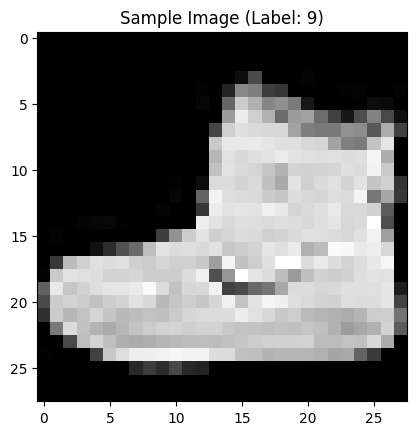

In [2]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Cargar el dataset Fashion-MNIST
# Los datos ya están divididos en entrenamiento y prueba por TensorFlow datasets
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"Shape of raw training images: {x_train_raw.shape}")
print(f"Shape of raw training labels: {y_train.shape}")
print(f"Shape of raw testing images: {x_test_raw.shape}")
print(f"Shape of raw testing labels: {y_test.shape}")

# Display a sample image
import matplotlib.pyplot as plt
plt.imshow(x_train_raw[0], cmap='gray')
plt.title(f"Sample Image (Label: {y_train[0]})")
plt.show()

### 2. Convertir matrices a tensores y realizar operaciones de Reshaping

Para modelos de red neuronal densa, es común aplanar las imágenes de 28x28 píxeles en un vector de 784 píxeles.

In [3]:
# Aplanar las imágenes de 28x28 a un vector de 784
x_train_flat = x_train_raw.reshape(-1, 28 * 28)
x_test_flat = x_test_raw.reshape(-1, 28 * 28)

print(f"Shape of flattened training images: {x_train_flat.shape}")
print(f"Shape of flattened testing images: {x_test_flat.shape}")

Shape of flattened training images: (60000, 784)
Shape of flattened testing images: (10000, 784)


### 3. Escalar los datos de entrada (MinMaxScaler)

Escalaremos los valores de los píxeles al rango [0, 1] utilizando `MinMaxScaler` para normalizar los datos, lo cual es beneficioso para el entrenamiento de redes neuronales.

In [4]:
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

print(f"Min value after scaling: {x_train_scaled.min()}")
print(f"Max value after scaling: {x_train_scaled.max()}")

Min value after scaling: 0.0
Max value after scaling: 1.0


### 4. Dividir el conjunto de datos (train_test_split)

Aunque Fashion-MNIST ya viene dividido, para fines de demostración de `train_test_split`, lo aplicaremos sobre el conjunto de entrenamiento original para obtener un conjunto de validación, o sobre el conjunto completo si fuera necesario. En este caso, usaremos el ya dividido `x_train_scaled` y `y_train` como nuestro conjunto "total" para simular una división 80/20 entre entrenamiento y validación si fuese necesario, pero para cumplir con la instrucción de Scikit-learn, vamos a dividir el conjunto de entrenamiento actual para crear un subconjunto de entrenamiento y un conjunto de validación.

In [5]:
# Dividir el conjunto de entrenamiento (x_train_scaled, y_train) en entrenamiento y validación
# Respetando la proporción estándar (80% entrenamiento, 20% validación)
x_train, x_val, y_train_split, y_val_split = train_test_split(x_train_scaled, y_train, test_size=0.2, random_state=42)

print(f"Shape of new training images: {x_train.shape}")
print(f"Shape of new training labels: {y_train_split.shape}")
print(f"Shape of validation images: {x_val.shape}")
print(f"Shape of validation labels: {y_val_split.shape}")
print(f"Shape of original testing images (scaled): {x_test_scaled.shape}")
print(f"Shape of original testing labels: {y_test.shape}")

Shape of new training images: (48000, 784)
Shape of new training labels: (48000,)
Shape of validation images: (12000, 784)
Shape of validation labels: (12000,)
Shape of original testing images (scaled): (10000, 784)
Shape of original testing labels: (10000,)


## FASE 3: Estructuración del Flujo de Datos (Data Pipeline) con TensorFlow y Keras

### 1. Convertir arreglos normalizados a tensores de TensorFlow

In [6]:
import tensorflow as tf

# Convertir los arreglos NumPy escalados a tensores de TensorFlow
x_train_tensor = tf.constant(x_train, dtype=tf.float32)
x_val_tensor = tf.constant(x_val, dtype=tf.float32)
x_test_tensor = tf.constant(x_test_scaled, dtype=tf.float32)

# Convertir las etiquetas a tensores de TensorFlow también
y_train_tensor = tf.constant(y_train_split, dtype=tf.int64)
y_val_tensor = tf.constant(y_val_split, dtype=tf.int64)
y_test_tensor = tf.constant(y_test, dtype=tf.int64)

print(f"Shape of x_train_tensor: {x_train_tensor.shape}")
print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
print(f"Shape of x_val_tensor: {x_val_tensor.shape}")
print(f"Shape of y_val_tensor: {y_val_tensor.shape}")
print(f"Shape of x_test_tensor: {x_test_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")

Shape of x_train_tensor: (48000, 784)
Shape of y_train_tensor: (48000,)
Shape of x_val_tensor: (12000, 784)
Shape of y_val_tensor: (12000,)
Shape of x_test_tensor: (10000, 784)
Shape of y_test_tensor: (10000,)


### 2. Estructurar un pipeline empleando `tf.data.Dataset.from_tensor_slices()`

Esto creará conjuntos de datos eficientes para el entrenamiento, validación y prueba.

In [7]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_tensor, y_train_tensor))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val_tensor, y_val_tensor))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_tensor, y_test_tensor))

print("tf.data.Dataset created successfully for training, validation, and testing.")

tf.data.Dataset created successfully for training, validation, and testing.


### 3. Encodificar las etiquetas (labels) mediante codificación One-Hot

Para problemas de clasificación multiclase, es esencial convertir las etiquetas enteras a formato One-Hot. Fashion-MNIST tiene 10 clases.

In [8]:
# Determinar el número de clases únicas en las etiquetas
num_classes = len(np.unique(y_train_split)) # Usamos y_train_split para obtener todas las clases posibles

# Aplicar One-Hot Encoding a las etiquetas
y_train_one_hot = tf.keras.utils.to_categorical(y_train_tensor.numpy(), num_classes=num_classes)
y_val_one_hot = tf.keras.utils.to_categorical(y_val_tensor.numpy(), num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_tensor.numpy(), num_classes=num_classes)

# Convertir las etiquetas one-hot de nuevo a tensores si es necesario para el dataset pipeline
y_train_one_hot_tensor = tf.constant(y_train_one_hot, dtype=tf.float32)
y_val_one_hot_tensor = tf.constant(y_val_one_hot, dtype=tf.float32)
y_test_one_hot_tensor = tf.constant(y_test_one_hot, dtype=tf.float32)

print(f"Shape of y_train_one_hot_tensor: {y_train_one_hot_tensor.shape}")
print(f"Shape of y_val_one_hot_tensor: {y_val_one_hot_tensor.shape}")
print(f"Shape of y_test_one_hot_tensor: {y_test_one_hot_tensor.shape}")

# Recrear los datasets con las etiquetas One-Hot
train_dataset_one_hot = tf.data.Dataset.from_tensor_slices((x_train_tensor, y_train_one_hot_tensor))
val_dataset_one_hot = tf.data.Dataset.from_tensor_slices((x_val_tensor, y_val_one_hot_tensor))
test_dataset_one_hot = tf.data.Dataset.from_tensor_slices((x_test_tensor, y_test_one_hot_tensor))

print("tf.data.Dataset recreated with One-Hot encoded labels successfully.")

Shape of y_train_one_hot_tensor: (48000, 10)
Shape of y_val_one_hot_tensor: (12000, 10)
Shape of y_test_one_hot_tensor: (10000, 10)
tf.data.Dataset recreated with One-Hot encoded labels successfully.
